# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

In [2]:
train_data = """Date,Location,Temp_Max_C,Temp_Min_C,Humidity_Pct,Wind_Speed_Kmh,Precipitation_mm,Weather_Type
2026-07-01,Singapore,31.5,25.0,82,16.5,4.2,Rainy
2026-07-02,Singapore,32.0,26.1,78,12.0,0.0,Sunny
2026-07-03,Singapore,30.8,24.5,85,25.4,18.0,Rainy
2026-07-04,Singapore,32.2,25.8,75,9.5,0.0,Sunny
2026-07-05,Singapore,31.0,25.2,80,14.2,2.1,Cloudy
2026-07-06,Singapore,31.8,26.0,77,11.0,0.0,Sunny
2026-07-07,Singapore,29.5,23.8,92,28.1,34.5,Rainy
2026-07-08,Singapore,31.2,25.5,81,13.0,0.5,Cloudy
2026-07-09,Singapore,32.5,26.3,74,10.2,0.0,Sunny
2026-07-10,Singapore,30.5,24.8,86,19.0,8.4,Rainy
2026-07-11,Singapore,32.1,25.9,76,11.5,0.0,Sunny
2026-07-12,Singapore,31.4,25.1,83,15.0,3.8,Rainy
2026-07-13,Singapore,31.0,25.3,82,12.8,1.2,Cloudy
2026-07-14,Singapore,32.4,26.2,73,8.7,0.0,Sunny
2026-07-15,Singapore,29.8,24.0,89,22.0,14.6,Rainy
2026-07-16,Singapore,31.6,25.6,79,13.4,0.0,Sunny
2026-07-17,Singapore,30.9,24.9,84,17.2,5.0,Rainy
2026-07-18,Singapore,32.0,25.8,77,10.6,0.0,Sunny
2026-07-19,Singapore,31.3,25.4,81,14.0,0.8,Cloudy
2026-07-20,Singapore,30.2,24.3,88,26.5,22.1,Rainy
2026-07-21,Singapore,32.6,26.5,72,9.0,0.0,Sunny
2026-07-22,Singapore,31.7,25.7,80,11.8,1.5,Cloudy
2026-07-23,Singapore,30.0,24.2,90,23.4,19.8,Rainy
2026-07-24,Singapore,32.3,26.0,76,10.5,0.0,Sunny"""


test_data = """Date,Location,Temp_Max_C,Temp_Min_C,Humidity_Pct,Wind_Speed_Kmh,Precipitation_mm,Weather_Type
2026-07-25,Singapore,31.1,25.2,83,13.2,2.7,Cloudy
2026-07-26,Singapore,32.8,26.6,71,8.1,0.0,Sunny
2026-07-27,Singapore,29.2,23.5,94,30.2,42.0,Rainy
2026-07-28,Singapore,31.5,25.4,79,12.6,0.0,Sunny
2026-07-29,Singapore,30.6,24.7,85,18.5,7.1,Rainy
2026-07-30,Singapore,31.9,25.9,78,11.1,0.0,Sunny"""

In [3]:
import io

train_df = pd.read_csv(io.StringIO(train_data))
test_df = pd.read_csv(io.StringIO(test_data))

# Select numerical features to learn from
features = ['Temp_Max_C', 'Temp_Min_C', 'Humidity_Pct', 'Wind_Speed_Kmh', 'Precipitation_mm']

X_train = train_df[features]
X_test = test_df[features]

# Convert target text (Sunny, Rainy, Cloudy) into numbers (0, 1, 2)
le = LabelEncoder()
y_train = le.fit_transform(train_df['Weather_Type'])
y_test = le.transform(test_df['Weather_Type'])

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (24, 5), y_train shape: (24,)
X_test shape: (6, 5), y_test shape: (6,)


In [4]:

# --- TRAIN & CALIBRATE THE MODEL ---
base_svm = SVC(probability=True, random_state=42)
calibrated_model = CalibratedClassifierCV(estimator=base_svm, method='sigmoid', cv=3)

# Train the calibrated model
calibrated_model.fit(X_train, y_train)

# --- PREDICT & INSPECT CONFIDENCE ---
# Predict classes and get the confidence scores for the test data
predictions = calibrated_model.predict(X_test)
probabilities = calibrated_model.predict_proba(X_test)

In [5]:
print("--- TEST DATA PREDICTIONS & CONFIDENCE ---")
for i in range(len(X_test)):
    true_label = le.inverse_transform([y_test[i]])[0]
    pred_label = le.inverse_transform([predictions[i]])[0]
    
    # Find the confidence score assigned to the predicted class
    pred_idx = predictions[i]
    confidence = probabilities[i][pred_idx] * 100
    
    print(f"Row {i+1} | True: {true_label:6} | Predicted: {pred_label:6} | Confidence: {confidence:.1f}%")

--- TEST DATA PREDICTIONS & CONFIDENCE ---
Row 1 | True: Cloudy | Predicted: Sunny  | Confidence: 47.0%
Row 2 | True: Sunny  | Predicted: Sunny  | Confidence: 49.3%
Row 3 | True: Rainy  | Predicted: Rainy  | Confidence: 81.4%
Row 4 | True: Sunny  | Predicted: Sunny  | Confidence: 47.9%
Row 5 | True: Rainy  | Predicted: Rainy  | Confidence: 45.7%
Row 6 | True: Sunny  | Predicted: Sunny  | Confidence: 48.2%


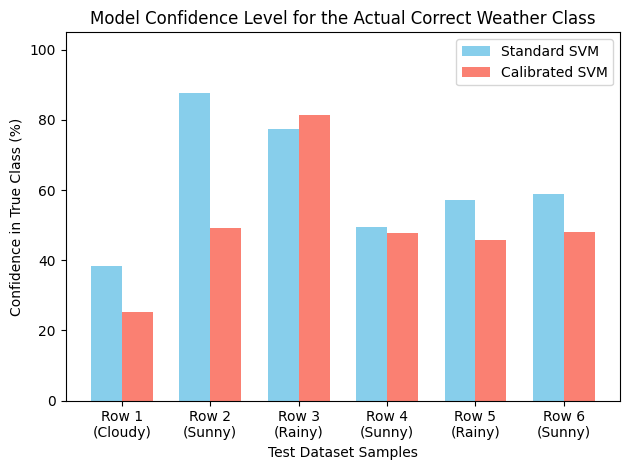

In [6]:
base_svm = SVC(probability=True, random_state=42).fit(X_train, y_train)
calibrated_model = CalibratedClassifierCV(estimator=SVC(probability=True, random_state=42), method='sigmoid', cv=3).fit(X_train, y_train)

# Extracted probability assigned to the CORRECT class
base_probs = base_svm.predict_proba(X_test)
cal_probs = calibrated_model.predict_proba(X_test)

rows = np.arange(len(X_test)) + 1
true_class_base_probs = [base_probs[i, y_test[i]] * 100 for i in range(len(X_test))]
true_class_cal_probs = [cal_probs[i, y_test[i]] * 100 for i in range(len(X_test))]

# Plotting
plt.clf()
width = 0.35
plt.bar(rows - width/2, true_class_base_probs, width, label='Standard SVM', color='skyblue')
plt.bar(rows + width/2, true_class_cal_probs, width, label='Calibrated SVM', color='salmon')

plt.xlabel('Test Dataset Samples')
plt.ylabel('Confidence in True Class (%)')
plt.title('Model Confidence Level for the Actual Correct Weather Class')
plt.xticks(rows, [f"Row {i}\n({le.inverse_transform([y_test[i-1]])[0]})" for i in rows])
plt.ylim(0, 105)
plt.legend()
plt.tight_layout()

### XGBoost

In [8]:
%uv pip install xgboost

Using Python 3.12.6 environment at: /usr/local
Resolved 4 packages in 97ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠼ Preparing packages... (0/1)
⠼ Preparing packages... (0/1)
⠼ Preparing packages... (

In [9]:
from xgboost import XGBClassifier

# --- TRAIN BASE XGBOOST vs CALIBRATED XGBOOST ---
# Base XGBoost
base_xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')
base_xgb.fit(X_train, y_train)

# Calibrated XGBoost (using Sigmoid / Platt Scaling)
calibrated_xgb = CalibratedClassifierCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'), method='sigmoid', cv=3)
calibrated_xgb.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'sigmoid'
,cv,3
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [10]:
# --- PREDICT & COMPARE PROBABILITIES ---
base_probs = base_xgb.predict_proba(X_test)
cal_probs = calibrated_xgb.predict_proba(X_test)
predictions = calibrated_xgb.predict(X_test)

print("--- XGBOOST CONFIDENCE COMPARISON ---")
for i in range(len(X_test)):
    true_label = le.inverse_transform([y_test[i]])[0]
    pred_label = le.inverse_transform([predictions[i]])[0]
    
    # Get probability assigned to the predicted class
    pred_idx = predictions[i]
    base_conf = base_probs[i][pred_idx] * 100
    cal_conf = cal_probs[i][pred_idx] * 100
    
    print(f"Row {i+1} | True: {true_label:6} | Predicted: {pred_label:6}")
    print(f"      -> Base XGBoost Confidence:       {base_conf:.1f}%")
    print(f"      -> Calibrated XGBoost Confidence: {cal_conf:.1f}%\n")

--- XGBOOST CONFIDENCE COMPARISON ---
Row 1 | True: Cloudy | Predicted: Cloudy
      -> Base XGBoost Confidence:       89.9%
      -> Calibrated XGBoost Confidence: 53.3%

Row 2 | True: Sunny  | Predicted: Sunny 
      -> Base XGBoost Confidence:       94.9%
      -> Calibrated XGBoost Confidence: 71.2%

Row 3 | True: Rainy  | Predicted: Rainy 
      -> Base XGBoost Confidence:       94.2%
      -> Calibrated XGBoost Confidence: 67.5%

Row 4 | True: Sunny  | Predicted: Sunny 
      -> Base XGBoost Confidence:       94.9%
      -> Calibrated XGBoost Confidence: 42.0%

Row 5 | True: Rainy  | Predicted: Rainy 
      -> Base XGBoost Confidence:       94.2%
      -> Calibrated XGBoost Confidence: 67.5%

Row 6 | True: Sunny  | Predicted: Sunny 
      -> Base XGBoost Confidence:       94.9%
      -> Calibrated XGBoost Confidence: 71.2%



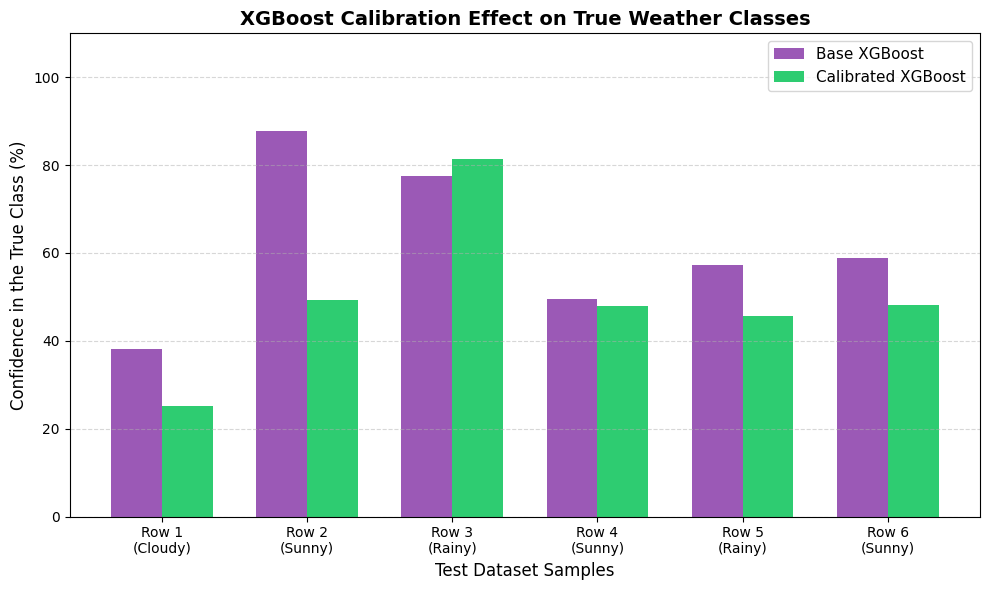

In [11]:
plt.figure(figsize=(10, 6))
width = 0.35  # width of the bars

# Create side-by-side bars
plt.bar(rows - width/2, true_class_base_probs, width, label='Base XGBoost', color='#9b59b6') # Purple
plt.bar(rows + width/2, true_class_cal_probs, width, label='Calibrated XGBoost', color='#2ecc71') # Green

# Styling and labels
plt.xlabel('Test Dataset Samples', fontsize=12)
plt.ylabel('Confidence in the True Class (%)', fontsize=12)
plt.title('XGBoost Calibration Effect on True Weather Classes', fontsize=14, fontweight='bold')

# Set x-ticks to display the index and the correct string label
labels = [f"Row {i}\n({le.inverse_transform([y_test[i-1]])[0]})" for i in rows]
plt.xticks(rows, labels)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11)

# Display the data directly on screen
plt.tight_layout()
plt.show()